# 🗺️ **Rasterization/Vectorization**

> ### 📌 **TL;DR**
>
> This Jupyter notebook has been created to compare different features with several open source Python libraries for rasters management.
>
> This notebook compares rasterization of vector data and vectorization of raster data.
>
> The following libraries will be considered :
>- `rasterio`
>- `rioxarray`
>- `odc-geo`
>- `geoutils`

In [1]:
import numpy as np

import geopandas as gpd

import rasterio
from rasterio import features
from rasterio.plot import show
from rasterio.transform import from_origin

import rioxarray

import geoutils as gu

import matplotlib.pyplot as plt

import seaborn as sns

#to be used with rioxarray
from geocube.api.core import make_geocube
from geocube.vector import vectorize

from shapely.geometry import shape

In [2]:
#path to the raster object
raster_path = "../data/rasters/subset_med.tif"

In [3]:
#path to the vector object
vector_path = "../data/vectors/buildings.shp"

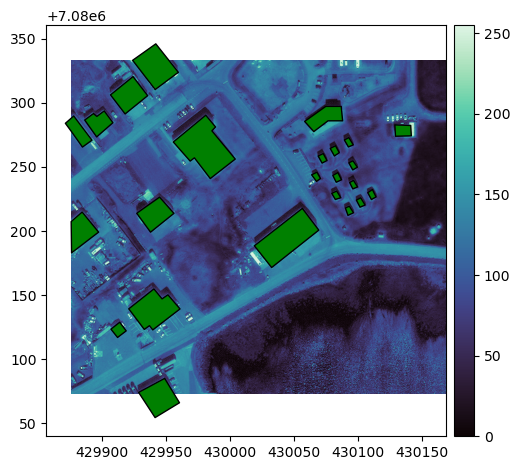

In [4]:
rast = gu.Raster(raster_path)
vect = gu.Vector(vector_path)

rast.plot(bands=1, cmap="mako")
vect.plot(fc="green", ec="k", lw=1)

## **Rasterize a vector**

Rasterizing is available in `rasterio`, `rioxarray` and `geoutils` libraries, but not implemented in `odc-geo`.

This method consists of converting a vector (shape) into a raster image.

In this example, we will transform building polygons (.shp) present in our image, to rasters.

### • *rasterio*

First, we have to create our `geopandas.DataFrame` containing geometries of our buildings polygons:

In [5]:
gdf = gpd.read_file(vector_path)

In [6]:
gdf["value"] = 1 #needed to use .rasterize later

Then we need to define the parameters of our output raster - transform, resolution, shape and CRS : 

In [7]:
resolution = 0.31 #res of our image
xmin, ymin, xmax, ymax = gdf.total_bounds
transform = from_origin(xmin, ymax, resolution, resolution)

width = int((xmax - xmin) / resolution)
height = int((ymax - ymin) / resolution)

We create an iterator of (geometry, value) that we will have to pass as an argument when rasterizing :

In [8]:
shapes = ((geom, value) for geom, value in zip(gdf["geometry"], gdf["value"]))

Finally, we will use the [`rasterize()`](https://rasterio.readthedocs.io/en/latest/api/rasterio.features.html#rasterio.features.rasterize) function:

For that, we have to pass several arguments, like the shapes we want to convert to raster, the output shape wanted (`out_shape`) and the transform matrix.

It will return an image with input geometries converted to rasters.

In [9]:
raster = features.rasterize(
    shapes=shapes,
    out_shape=(height, width),
    transform=transform,
    fill=0, #value for nodata
    dtype="int32"
)

We can plot our image to see the result:

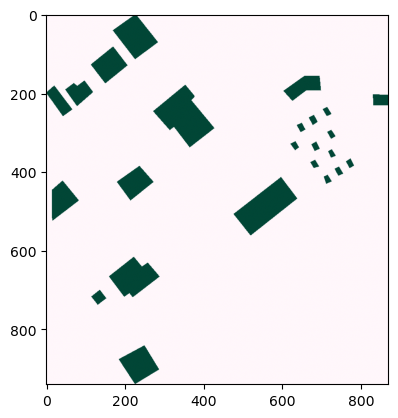

<Axes: >

In [10]:
show(raster, cmap="PuBuGn")

### • *rioxarray*

Rasterizing a vector is not possible directly through `rioxarray`, so we will have to use another library, namely `geocube`.

In particular we will call the [`geocube.make_geocube()`](https://corteva.github.io/geocube/html/geocube.html) function for this matter:

It will rasterize a vector into an `xarray` object. We will pass as arguments our geodataframe containing vectors, and specify the resolution of our pixels:

In [11]:
cube = make_geocube(vector_data=gdf, resolution=(-0.31, 0.31))

The object created is an `xarray.Dataset`, as we can see:

In [12]:
cube

<xarray.Dataset> Size: 13MB
Dimensions:      (y: 941, x: 871)
Coordinates:
  * y            (y) float64 8kB 7.08e+06 7.08e+06 ... 7.08e+06 7.08e+06
  * x            (x) float64 7kB 4.299e+05 4.299e+05 ... 4.301e+05 4.301e+05
    spatial_ref  int64 8B 0
Data variables:
    id           (y, x) float64 7MB nan nan nan nan nan ... nan nan nan nan nan
    value        (y, x) float64 7MB nan nan nan nan nan ... nan nan nan nan nan

We can check the result by plotting the new raster:

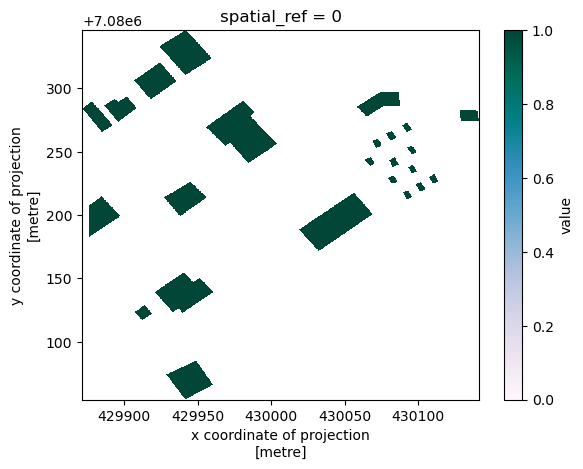

In [13]:
cube["value"].plot(cmap="PuBuGn", vmin=0)
plt.show()

### • *geoutils*

With `geoutils`, we will use the [`rasterize()`](https://geoutils.readthedocs.io/en/stable/gen_modules/geoutils.Vector.rasterize.html#geoutils.Vector.rasterize) function:

In [14]:
gu_rast = gu.Raster(raster_path)

gu_vect = gu.Vector(vector_path)

If we plot our polygons above the raster:

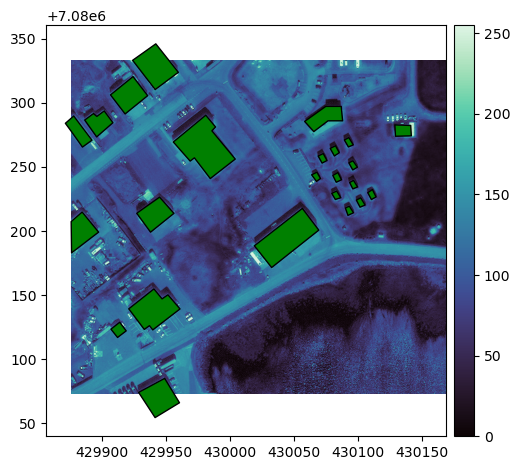

In [15]:
gu_rast.plot(bands=1, cmap="mako")
gu_vect.plot(ref_crs=gu_rast, fc= "green", ec="k", lw=1)

Next, we use the `.rasterize()` function on our vectors to convert them to rasters. As arguments, we will pass our reference raster to match, and the values to be burned inside the polygons (`in_value`) :

In [16]:
vect_rasterized = gu_vect.rasterize(gu_rast, in_value=1) #in_value = 1 to burn a single value

If we plot the map, here is the result, focused on our area of study:

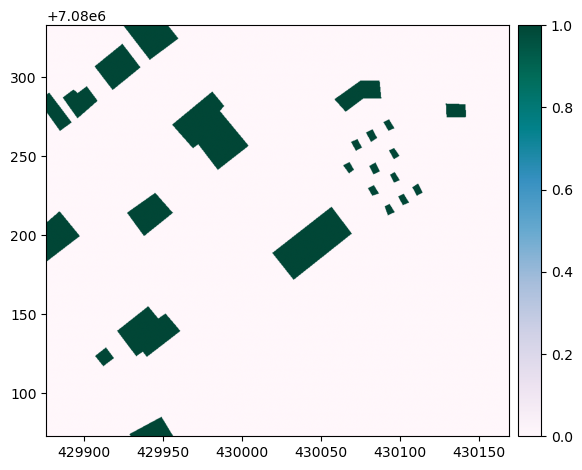

In [17]:
vect_rasterized.plot(cmap="PuBuGn")

## **Vectorize a raster**

Vectorizing a raster is available in `rasterio`, `rioxarray` and `geoutils` libraries, but not implemented in `odc-geo`.

This method is the opposite of the previous section, it consists of converting a raster into a vector (shape).

This time, we will focus on a raster of the north of Sardinia (small part for processing purposes), and will convert it to a shape.

In [18]:
#path to the raster object
raster_path = "../data/rasters/sard2.tif"

### • *rasterio*

In `rasterio`, we first need to select a band and get its positional metadata (transform and CRS).

We will also create a shape object which is an iterator containing (geometry, value) pairs:

In [19]:
with rasterio.open(raster_path) as src:
    b1 = src.read(1)
    transform = src.transform
    crs = src.crs

shapes = features.shapes(b1, transform=transform)

We will then create two lists containing our geometries (converted from geojson to shapely) and the associated values for each geometry:

In [20]:
geom_list = []
value_list = []

for geom, value in shapes:
    geom_list.append(shape(geom)) #convert from geojson to shapely
    value_list.append(value)

After that, we have to create our GeoDataFrame. We will pass as arguments our lists previously created, and the CRS:

In [21]:
gdf = gpd.GeoDataFrame({"value": value_list, "geometry": geom_list}, crs=crs)

Finally, we can plot our new vector:

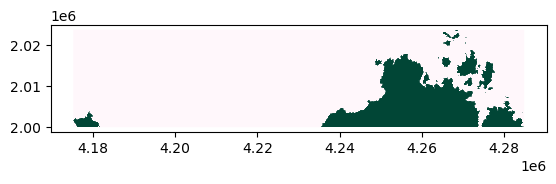

In [22]:
gdf.plot(column="value", cmap="PuBuGn")
plt.show()

### • *rioxarray*

For `rioxarray`, we will use again the geocube library and especially the [`geocube.vectorize()`](https://corteva.github.io/geocube/html/geocube.html#geocube.vector.vectorize) function:

In [23]:
da_rxr = rioxarray.open_rasterio(raster_path)

We now use the `vectorize()` function from `geocube`. We just need to pass the raster to be vectorized as an argument:

In [24]:
da_rxr_vectorized = vectorize(da_rxr)

c:\Users\cbernaert\AppData\Local\anaconda3\envs\rasters_lib_comp\Lib\site-packages\geocube\vector.py:62: UserWarning: The array has no name. Column name defaults to _data
  warnings.warn("The array has no name. Column name defaults to _data")


We can finally plot the result:

<Axes: >

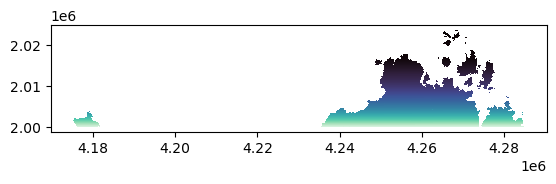

In [25]:
da_rxr_vectorized.plot(cmap="mako")

### • *geoutils*

With `geoutils`, we will use the [`polygonize()`](https://geoutils.readthedocs.io/en/stable/gen_modules/geoutils.Raster.polygonize.html#geoutils.Raster.polygonize) function to vectorize our raster:

In [26]:
gu_rast = gu.Raster(raster_path)

Here is the raster before being converted to a vector:

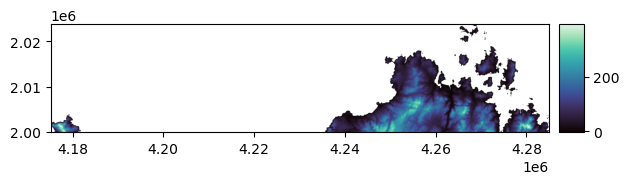

In [27]:
gu_rast.plot(cmap="mako")

Here we call the function `polygonize`:

In [28]:
rast_polygonized = gu_rast.polygonize()

c:\Users\cbernaert\AppData\Local\anaconda3\envs\rasters_lib_comp\Lib\site-packages\numpy\ma\core.py:509: RuntimeWarning: invalid value encountered in cast
  fill_value = np.asarray(fill_value, dtype=ndtype)
c:\Users\cbernaert\AppData\Local\anaconda3\envs\rasters_lib_comp\Lib\site-packages\geoutils\interface\raster_vector.py:100: RuntimeWarning: invalid value encountered in cast
  shapes(source_raster.data.astype(final_dtype), mask=bool_msk, transform=source_raster.transform)


The returned object is a `geoutils.Vector` containing all vectorized geometries and their values:

In [29]:
rast_polygonized

Vector(
  ds=            id                                           geometry  \
       0            0  POLYGON ((4268425 2023700, 4268425 2023675, 42...   
       1            1  POLYGON ((4268450 2023700, 4268450 2023675, 42...   
       2            2  POLYGON ((4268500 2023700, 4268500 2023675, 42...   
       3            3  POLYGON ((4268575 2023700, 4268575 2023675, 42...   
       4            4  POLYGON ((4268625 2023700, 4268625 2023675, 42...   
       ...        ...                                                ...   
       456612  456612  POLYGON ((4284250 2000025, 4284250 2000000, 42...   
       456613  456613  POLYGON ((4284275 2000025, 4284275 2000000, 42...   
       456614  456614  POLYGON ((4284300 2000025, 4284300 2000000, 42...   
       456615  456615  POLYGON ((4284325 2000025, 4284325 2000000, 42...   
       456616  456616  POLYGON ((4284350 2000025, 4284350 2000000, 42...   
       
               raster_value  
       0                2.0  
       1                3.0  
       2                4.0  
       3                3.0  
       4                2.0  
       ...              ...  
       456612          11.0  
       456613           8.0  
       456614           6.0  
       456615           3.0  
       456616           0.0  
       
       [456617 rows x 3 columns]
  crs=PROJCS["ETRS89_ETRS_LAEA",GEOGCS["ETRS89",DATUM["European_Terrestrial_Reference_System_1989",SPHEROID["GRS 1980",6378137,298.257222101004,AUTHORITY["EPSG","7019"]],AUTHORITY["EPSG","6258"]],PRIMEM["Greenwich",0],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AUTHORITY["EPSG","4258"]],PROJECTION["Lambert_Azimuthal_Equal_Area"],PARAMETER["latitude_of_center",52],PARAMETER["longitude_of_center",10],PARAMETER["false_easting",4321000],PARAMETER["false_northing",3210000],UNIT["metre",1],AXIS["Easting",EAST],AXIS["Northing",NORTH]]
  bounds=BoundingBox(left=np.float64(4175250.0), bottom=np.float64(2000000.0), right=np.float64(4284875.0), top=np.float64(2023700.0)))

And we can finally plot the result:

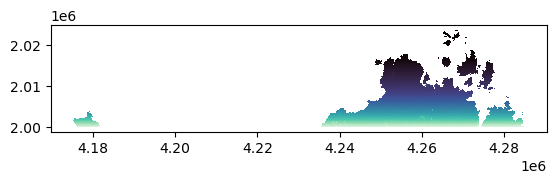

In [30]:
rast_polygonized.plot(cmap="mako")